# Understanding the Pair Plot

A pair plot (scatter matrix) arranges every feature combination in a grid. The **diagonal** shows each variable's own distribution; the **off-diagonal** cells show the bivariate relationship between each pair. Colouring by the target variable turns it into a powerful feature-selection tool.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

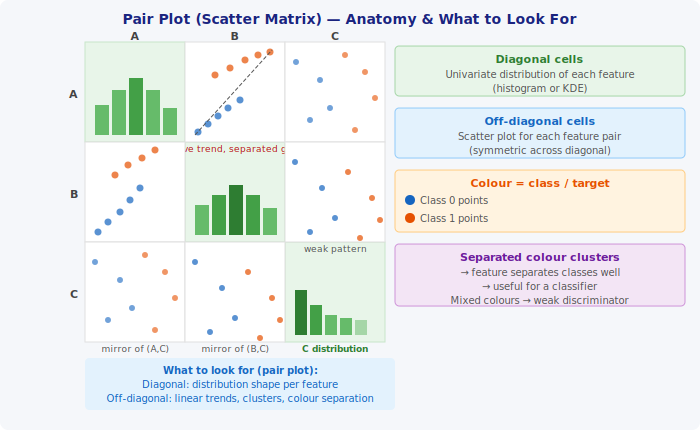

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="700" height="430" fill="#F5F7FA" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Pair Plot (Scatter Matrix) — Anatomy &amp; What to Look For</text>

  <!-- 3x3 grid, cell size 100x100, grid origin at (85, 42) -->

  <!-- Row / col labels -->
  <text x="135" y="40" text-anchor="middle" font-size="11" font-weight="bold" fill="#424242">A</text>
  <text x="235" y="40" text-anchor="middle" font-size="11" font-weight="bold" fill="#424242">B</text>
  <text x="335" y="40" text-anchor="middle" font-size="11" font-weight="bold" fill="#424242">C</text>
  <text x="78"  y="98" text-anchor="end"    font-size="11" font-weight="bold" fill="#424242">A</text>
  <text x="78"  y="198" text-anchor="end"   font-size="11" font-weight="bold" fill="#424242">B</text>
  <text x="78"  y="298" text-anchor="end"   font-size="11" font-weight="bold" fill="#424242">C</text>

  <!-- ── Diagonal cells (histograms/KDE per feature) ── -->
  <!-- (0,0): Feature A histogram -->
  <rect x="85" y="42" width="100" height="100" fill="#E8F5E9" stroke="#C8E6C9"/>
  <rect x="95"  y="105" width="14" height="30" fill="#66BB6A"/>
  <rect x="112" y="90"  width="14" height="45" fill="#66BB6A"/>
  <rect x="129" y="78"  width="14" height="57" fill="#43A047"/>
  <rect x="146" y="90"  width="14" height="45" fill="#66BB6A"/>
  <rect x="163" y="108" width="14" height="27" fill="#66BB6A"/>
  <text x="135" y="152" text-anchor="middle" font-size="9" fill="#2E7D32" font-weight="bold">A distribution</text>

  <!-- (1,1): Feature B histogram -->
  <rect x="185" y="142" width="100" height="100" fill="#E8F5E9" stroke="#C8E6C9"/>
  <rect x="195" y="205" width="14" height="30" fill="#66BB6A"/>
  <rect x="212" y="195" width="14" height="40" fill="#43A047"/>
  <rect x="229" y="185" width="14" height="50" fill="#2E7D32"/>
  <rect x="246" y="195" width="14" height="40" fill="#43A047"/>
  <rect x="263" y="208" width="14" height="27" fill="#66BB6A"/>
  <text x="235" y="252" text-anchor="middle" font-size="9" fill="#2E7D32" font-weight="bold">B distribution</text>

  <!-- (2,2): Feature C histogram -->
  <rect x="285" y="242" width="100" height="100" fill="#E8F5E9" stroke="#C8E6C9"/>
  <rect x="295" y="290" width="12" height="45" fill="#2E7D32"/>
  <rect x="310" y="305" width="12" height="30" fill="#43A047"/>
  <rect x="325" y="315" width="12" height="20" fill="#66BB6A"/>
  <rect x="340" y="318" width="12" height="17" fill="#66BB6A"/>
  <rect x="355" y="320" width="12" height="15" fill="#A5D6A7"/>
  <text x="335" y="352" text-anchor="middle" font-size="9" fill="#2E7D32" font-weight="bold">C distribution</text>

  <!-- ── Off-diagonal cells: scatter plots ── -->
  <!-- (0,1): A vs B — strong positive correlation, two coloured groups -->
  <rect x="185" y="42" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <!-- Group 0 (blue) -->
  <circle cx="198" cy="132" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="208" cy="124" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="218" cy="116" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="228" cy="108" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="240" cy="100" r="3.5" fill="#1565C0" opacity="0.7"/>
  <!-- Group 1 (orange) -->
  <circle cx="215" cy="75" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="230" cy="68" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="245" cy="60" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="258" cy="55" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="270" cy="52" r="3.5" fill="#E65100" opacity="0.7"/>
  <!-- Trend line -->
  <line x1="195" y1="135" x2="272" y2="50" stroke="#555" stroke-width="1" stroke-dasharray="4,2"/>
  <text x="235" y="152" text-anchor="middle" font-size="9" fill="#B71C1C">positive trend, separated groups</text>

  <!-- (0,2): A vs C — no relationship (scattered cloud) -->
  <rect x="285" y="42" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <circle cx="296" cy="62"  r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="310" cy="120" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="320" cy="80"  r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="330" cy="108" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="345" cy="55"  r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="355" cy="130" r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="365" cy="72"  r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="375" cy="98"  r="3" fill="#E65100" opacity="0.6"/>
  <text x="335" y="152" text-anchor="middle" font-size="9" fill="#555">no pattern (r ≈ 0)</text>

  <!-- (1,0): B vs A — same as (0,1) transposed -->
  <rect x="85" y="142" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <circle cx="98"  cy="232" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="108" cy="222" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="120" cy="212" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="130" cy="200" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="140" cy="188" r="3.5" fill="#1565C0" opacity="0.7"/>
  <circle cx="115" cy="175" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="128" cy="165" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="142" cy="158" r="3.5" fill="#E65100" opacity="0.7"/>
  <circle cx="155" cy="150" r="3.5" fill="#E65100" opacity="0.7"/>
  <text x="135" y="252" text-anchor="middle" font-size="9" fill="#B71C1C">mirror of (A,B)</text>

  <!-- (2,0): C vs A -->
  <rect x="85" y="242" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <circle cx="95"  cy="262" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="108" cy="320" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="120" cy="280" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="132" cy="308" r="3" fill="#1565C0" opacity="0.6"/>
  <circle cx="145" cy="255" r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="155" cy="330" r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="165" cy="272" r="3" fill="#E65100" opacity="0.6"/>
  <circle cx="175" cy="298" r="3" fill="#E65100" opacity="0.6"/>
  <text x="135" y="352" text-anchor="middle" font-size="9" fill="#555">mirror of (A,C)</text>

  <!-- (1,2): B vs C -->
  <rect x="285" y="142" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <circle cx="295" cy="162" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="310" cy="232" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="322" cy="188" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="335" cy="218" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="348" cy="172" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="360" cy="238" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="372" cy="198" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="380" cy="220" r="3" fill="#E65100" opacity="0.7"/>
  <text x="335" y="252" text-anchor="middle" font-size="9" fill="#555">weak pattern</text>

  <!-- (2,1): C vs B -->
  <rect x="185" y="242" width="100" height="100" fill="white" stroke="#E0E0E0"/>
  <circle cx="195" cy="262" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="210" cy="332" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="222" cy="288" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="235" cy="318" r="3" fill="#1565C0" opacity="0.7"/>
  <circle cx="248" cy="272" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="260" cy="338" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="272" cy="298" r="3" fill="#E65100" opacity="0.7"/>
  <circle cx="280" cy="320" r="3" fill="#E65100" opacity="0.7"/>
  <text x="235" y="352" text-anchor="middle" font-size="9" fill="#555">mirror of (B,C)</text>

  <!-- ANNOTATIONS -->
  <!-- Diagonal label -->
  <rect x="395" y="46" width="290" height="50" fill="#E8F5E9" rx="4" stroke="#A5D6A7"/>
  <text x="540" y="63" text-anchor="middle" font-size="11" font-weight="bold" fill="#2E7D32">Diagonal cells</text>
  <text x="540" y="78" text-anchor="middle" font-size="10" fill="#555">Univariate distribution of each feature</text>
  <text x="540" y="92" text-anchor="middle" font-size="10" fill="#555">(histogram or KDE)</text>

  <!-- Off-diagonal label -->
  <rect x="395" y="108" width="290" height="50" fill="#E3F2FD" rx="4" stroke="#90CAF9"/>
  <text x="540" y="125" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565C0">Off-diagonal cells</text>
  <text x="540" y="140" text-anchor="middle" font-size="10" fill="#555">Scatter plot for each feature pair</text>
  <text x="540" y="154" text-anchor="middle" font-size="10" fill="#555">(symmetric across diagonal)</text>

  <!-- Color = target label -->
  <rect x="395" y="170" width="290" height="62" fill="#FFF3E0" rx="4" stroke="#FFCC80"/>
  <text x="540" y="187" text-anchor="middle" font-size="11" font-weight="bold" fill="#E65100">Colour = class / target</text>
  <circle cx="410" cy="200" r="5" fill="#1565C0"/>
  <text x="420" y="204" font-size="10" fill="#555">Class 0 points</text>
  <circle cx="410" cy="218" r="5" fill="#E65100"/>
  <text x="420" y="222" font-size="10" fill="#555">Class 1 points</text>

  <!-- Separation = good feature -->
  <rect x="395" y="244" width="290" height="62" fill="#F3E5F5" rx="4" stroke="#CE93D8"/>
  <text x="540" y="261" text-anchor="middle" font-size="11" font-weight="bold" fill="#6A1B9A">Separated colour clusters</text>
  <text x="540" y="276" text-anchor="middle" font-size="10" fill="#555">→ feature separates classes well</text>
  <text x="540" y="290" text-anchor="middle" font-size="10" fill="#555">→ useful for a classifier</text>
  <text x="540" y="304" text-anchor="middle" font-size="10" fill="#555">Mixed colours → weak discriminator</text>

  <!-- Bottom takeaway -->
  <rect x="85" y="358" width="310" height="52" fill="#E3F2FD" rx="4"/>
  <text x="240" y="374" text-anchor="middle" font-size="10" fill="#1565C0" font-weight="bold">What to look for (pair plot):</text>
  <text x="240" y="388" text-anchor="middle" font-size="10" fill="#1565C0">Diagonal: distribution shape per feature</text>
  <text x="240" y="402" text-anchor="middle" font-size="10" fill="#1565C0">Off-diagonal: linear trends, clusters, colour separation</text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Pair Plot

| Cell | What to look for |
|---|---|
| **Diagonal** | Distribution shape of each feature |
| **Off-diagonal — linear trend** | High Pearson r between the two features |
| **Off-diagonal — scattered cloud** | Low correlation |
| **Separated colour clusters** | Feature is a good discriminator for the target |
| **Mixed colour cloud** | Feature does not separate the classes |
| **Diagonal — separated colour peaks** | Feature distributions differ by class |

**Pair plot at a glance**: in one figure you can identify correlated features (multicollinearity risk), good features for the model, and outliers that stand alone across multiple panels.

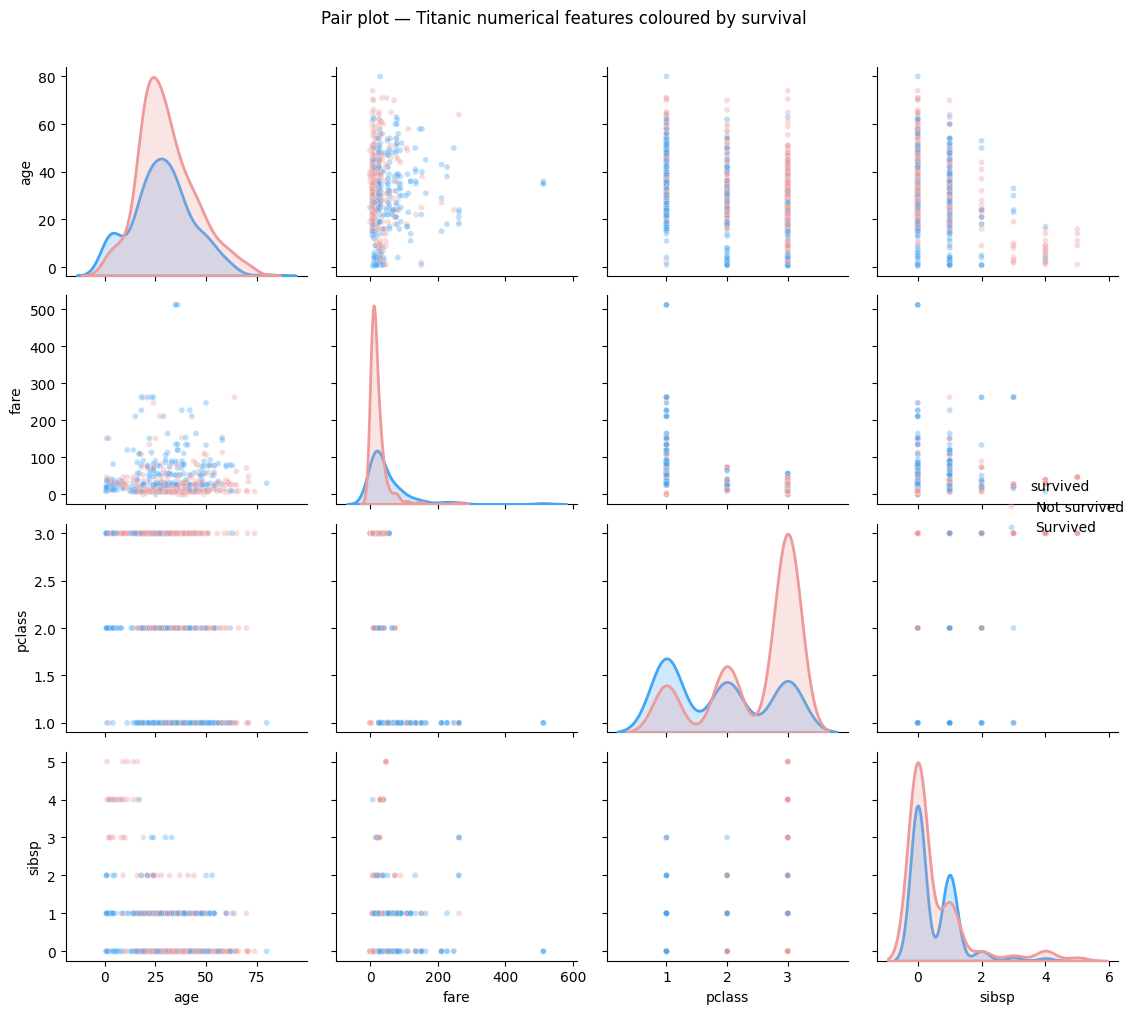

In [3]:
df = sns.load_dataset('titanic')
cols = ['age', 'fare', 'pclass', 'sibsp', 'survived']
plot_df = df[cols].dropna()
plot_df['survived'] = plot_df['survived'].map({0:'Not survived', 1:'Survived'})

g = sns.pairplot(plot_df, hue='survived',
                 palette={'Not survived':'#EF9A9A', 'Survived':'#42A5F5'},
                 diag_kind='kde',
                 plot_kws=dict(alpha=0.35, s=18),
                 diag_kws=dict(linewidth=2))

g.fig.suptitle('Pair plot — Titanic numerical features coloured by survival',
               fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Multivariate overview — all pairs at once |
| **Diagonal** | Univariate distribution (KDE or histogram) per feature |
| **Colour by target** | Reveals which features discriminate between classes |
| **Correlated off-diagonal** | Diagonal trend → multicollinearity risk |
| **Scales poorly** | With > 6–8 features the grid becomes unreadable — use correlation heatmap instead |